In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
# exploratory data analysis

In [3]:
# basic statistics 

In [4]:
data = pd.read_csv("C:/Users/anves/OneDrive/Documents/Anvesha/KodeinKGP/hypertension_data.csv")

In [5]:
data.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


In [6]:
data.tail()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
1980,56,10.2,0,Normal,6.5,25.0,Diuretic,Yes,Low,Non-Smoker,Yes
1981,29,8.9,4,Hypertension,6.9,16.9,NaN,Yes,High,Non-Smoker,Yes
1982,64,5.9,9,Normal,5.6,18.9,ACE Inhibitor,Yes,Moderate,Non-Smoker,Yes
1983,35,7.4,8,Prehypertension,8.2,29.2,NaN,Yes,Moderate,Non-Smoker,No
1984,38,7.3,0,Normal,8.3,18.6,NaN,Yes,Low,Smoker,No


In [7]:
data.shape

(1985, 11)

In [8]:
data.describe()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


In [9]:
data.columns

Index(['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration',
       'BMI', 'Medication', 'Family_History', 'Exercise_Level',
       'Smoking_Status', 'Has_Hypertension'],
      dtype='object')

In [10]:
data.nunique()

Age                  67
Salt_Intake         121
Stress_Score         11
BP_History            3
Sleep_Duration       88
BMI                 236
Medication            4
Family_History        2
Exercise_Level        3
Smoking_Status        2
Has_Hypertension      2
dtype: int64

In [11]:
data['Exercise_Level'].unique()

array(['Low', 'Moderate', 'High'], dtype=object)

In [12]:
# check missing values

In [13]:
data.isnull().sum()

Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64

In [14]:
# removing strings to make heatmap 

In [15]:
patient = data.drop(['BP_History', 'Medication', 'Family_History', 'Exercise_Level', 'Smoking_Status', 'Has_Hypertension'], axis=1)

In [16]:
patient.head()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
0,69,8.0,9,6.4,25.8
1,32,11.7,10,5.4,23.4
2,78,9.5,3,7.1,18.7
3,38,10.0,10,4.2,22.1
4,41,9.8,1,5.8,16.2


In [17]:
# visualising key trends

In [18]:
corelation = patient.corr()

<Axes: >

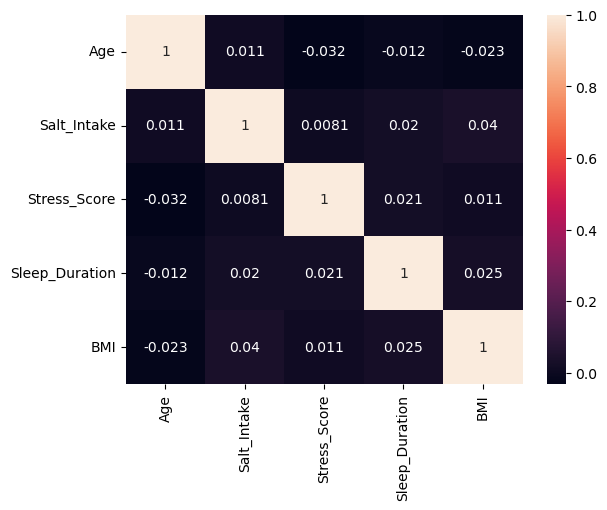

In [19]:
sns.heatmap(corelation, xticklabels = corelation.columns, yticklabels = corelation.columns, annot = True)

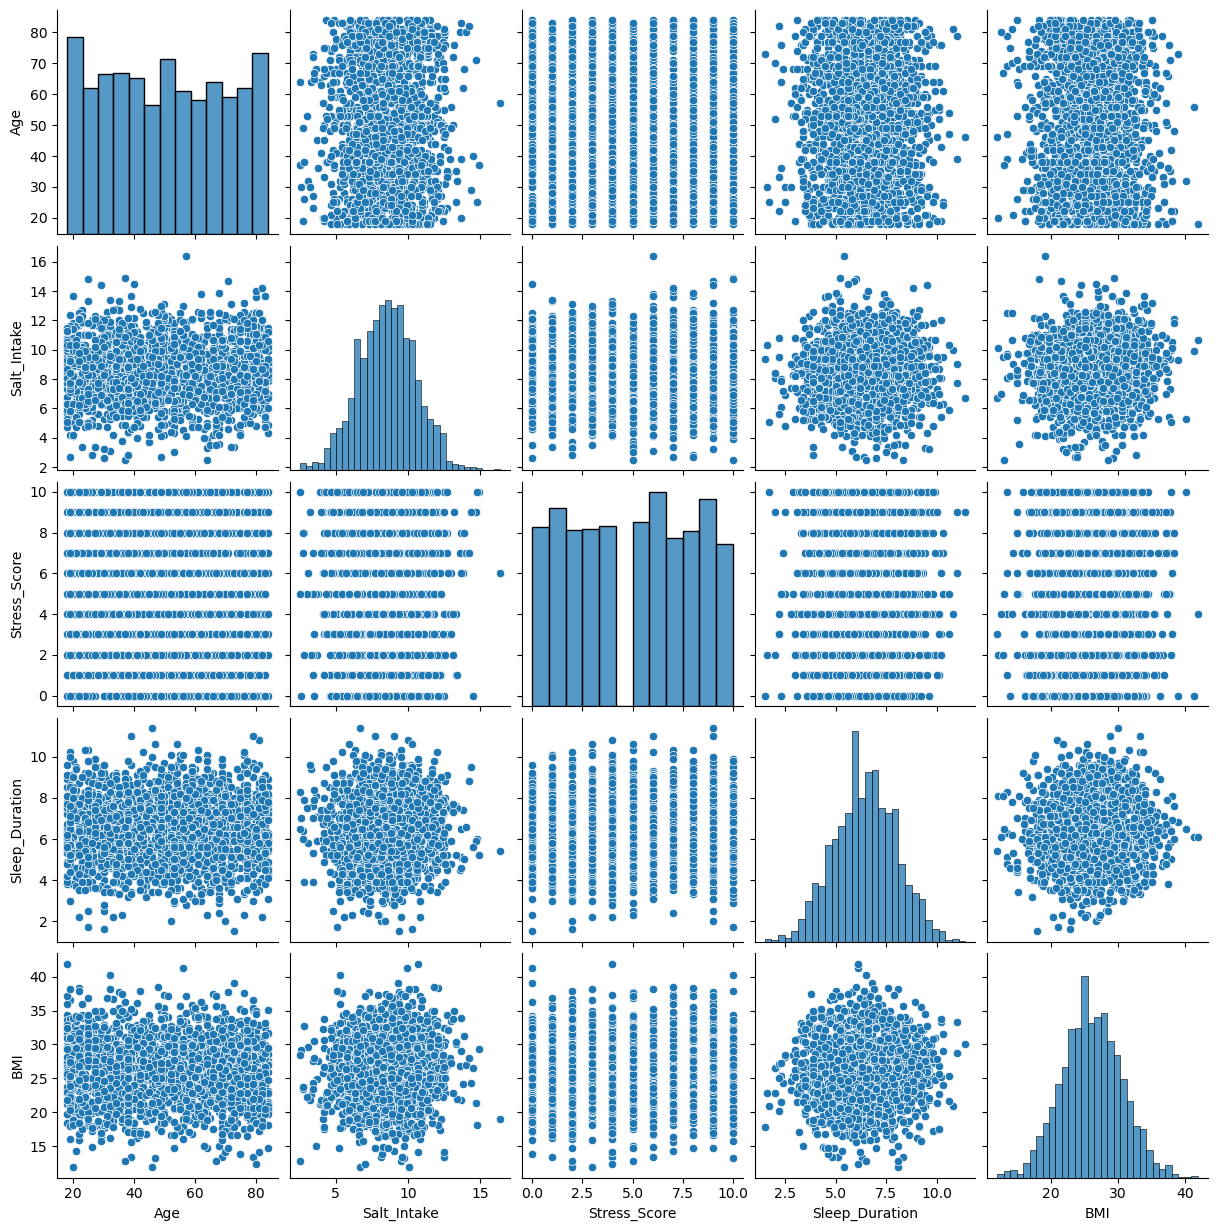

In [20]:
sns.pairplot(patient)

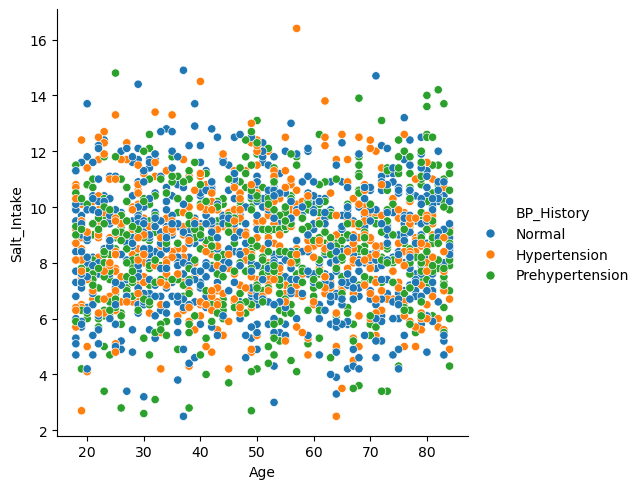

In [21]:
sns.relplot(x='Age', y='Salt_Intake', hue='BP_History', data=data)

C:\Users\anves\AppData\Local\Temp\ipykernel_9512\2317092479.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Age'])


<Axes: xlabel='Age', ylabel='Density'>

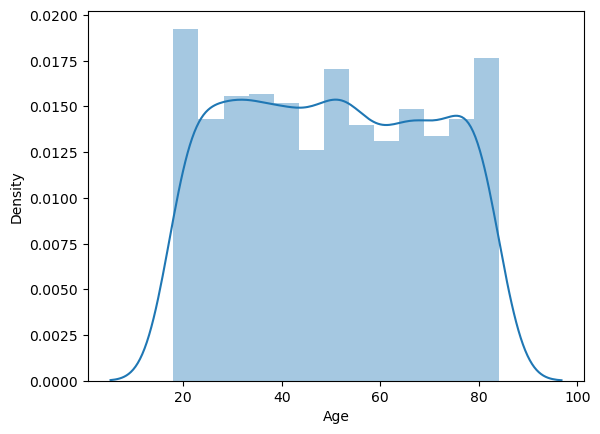

In [22]:
sns.distplot(data['Age'])

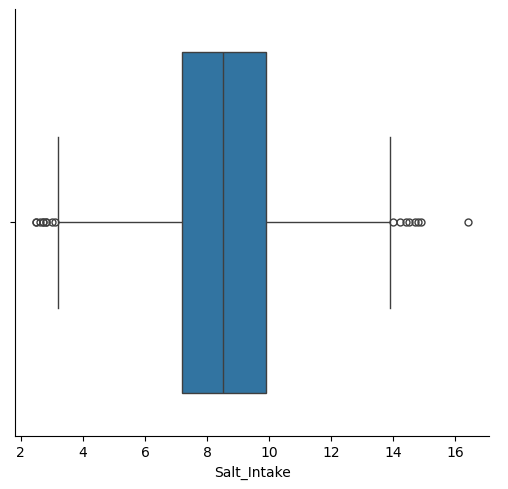

In [23]:
sns.catplot(x='Salt_Intake', kind='box', data=data)

In [24]:
# pre-processing steps 

In [25]:
# handling missing values => removing Medication column because it has null and discrete values which wouldn't be very helpful while making prediction

In [26]:
data_new = data.drop(['Medication'], axis=1)

In [27]:
# making 2 copies because we will use second one for further calculations

In [28]:
data_new_1 = data.drop(['Medication'], axis=1)

In [29]:
data_new.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,No,Moderate,Non-Smoker,No


In [30]:
# encode categorical features

In [31]:
categorical_cols = ['BP_History', 'Family_History', 'Exercise_Level', 'Smoking_Status']
data_new = pd.get_dummies(data_new, columns=categorical_cols)

In [32]:
data_new.head()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI,Has_Hypertension,BP_History_Hypertension,BP_History_Normal,BP_History_Prehypertension,Family_History_No,Family_History_Yes,Exercise_Level_High,Exercise_Level_Low,Exercise_Level_Moderate,Smoking_Status_Non-Smoker,Smoking_Status_Smoker
0,69,8.0,9,6.4,25.8,Yes,False,True,False,False,True,False,True,False,True,False
1,32,11.7,10,5.4,23.4,No,False,True,False,True,False,False,True,False,True,False
2,78,9.5,3,7.1,18.7,No,False,True,False,True,False,False,False,True,True,False
3,38,10.0,10,4.2,22.1,Yes,True,False,False,True,False,False,True,False,True,False
4,41,9.8,1,5.8,16.2,No,False,False,True,True,False,False,False,True,True,False


In [33]:
# scaling numerical features 

In [34]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_new[['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI']] = scaler.fit_transform(data_new[['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI']])

In [35]:
data_new.head()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI,Has_Hypertension,BP_History_Hypertension,BP_History_Normal,BP_History_Prehypertension,Family_History_No,Family_History_Yes,Exercise_Level_High,Exercise_Level_Low,Exercise_Level_Moderate,Smoking_Status_Non-Smoker,Smoking_Status_Smoker
0,0.772727,0.395683,0.9,0.494949,0.463333,Yes,False,True,False,False,True,False,True,False,True,False
1,0.212121,0.661871,1.0,0.393939,0.383333,No,False,True,False,True,False,False,True,False,True,False
2,0.909091,0.503597,0.3,0.565657,0.226667,No,False,True,False,True,False,False,False,True,True,False
3,0.303030,0.539568,1.0,0.272727,0.340000,Yes,True,False,False,True,False,False,True,False,True,False
4,0.348485,0.525180,0.1,0.434343,0.143333,No,False,False,True,True,False,False,False,True,True,False


In [36]:
# checking for outliers 

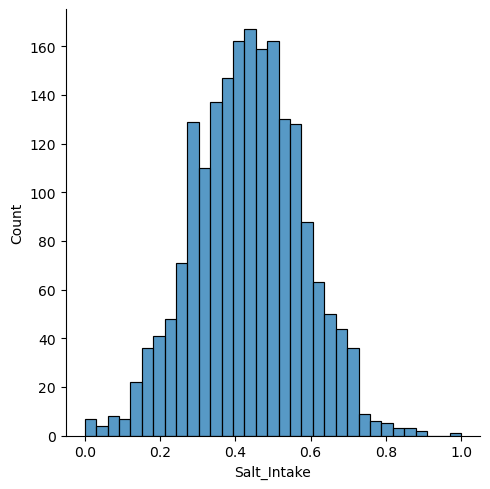

In [37]:
sns.displot(data = data_new, x='Salt_Intake')

In [38]:
# values between 0.8 and 1.0 are outliers 

In [39]:
# removing outliers 

In [40]:
data_new['Salt_Intake'] = data_new['Salt_Intake'].clip(upper=0.9)

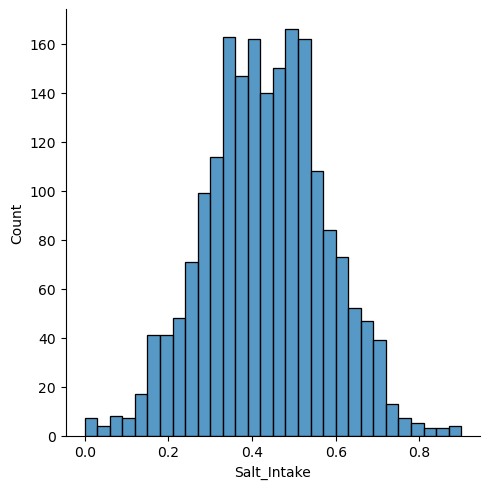

In [41]:
sns.displot(data = data_new, x='Salt_Intake')

In [42]:
# making train-test split (80-20) using data_new_1

In [46]:
X = data_new.drop('Has_Hypertension', axis=1)  
y = data_new['Has_Hypertension']               

In [43]:
# telling model which columns are features and which are labels

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [48]:
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (1588, 15) (1588,)
Test shape: (397, 15) (397,)


In [44]:
# building decision trees

In [45]:
# unpruned tree

In [50]:
from sklearn.tree import DecisionTreeClassifier
unpruned_tree = DecisionTreeClassifier().fit(X_train, y_train)

In [51]:
score_train_unpruned_tree = unpruned_tree.score(X_train, y_train)
score_test_unpruned_tree = unpruned_tree.score(X_test, y_test)

In [52]:
train_scores = [score_train_unpruned_tree]
test_scores = [score_test_unpruned_tree]
model_list = ['unpruned_tree']
score_dict = {
    'train_score':train_scores,
    'test_score':test_scores,
}
data_new_score = pd.DataFrame(score_dict, index=model_list)
data_new_score

,train_score,test_score
unpruned_tree,1.0,0.962217


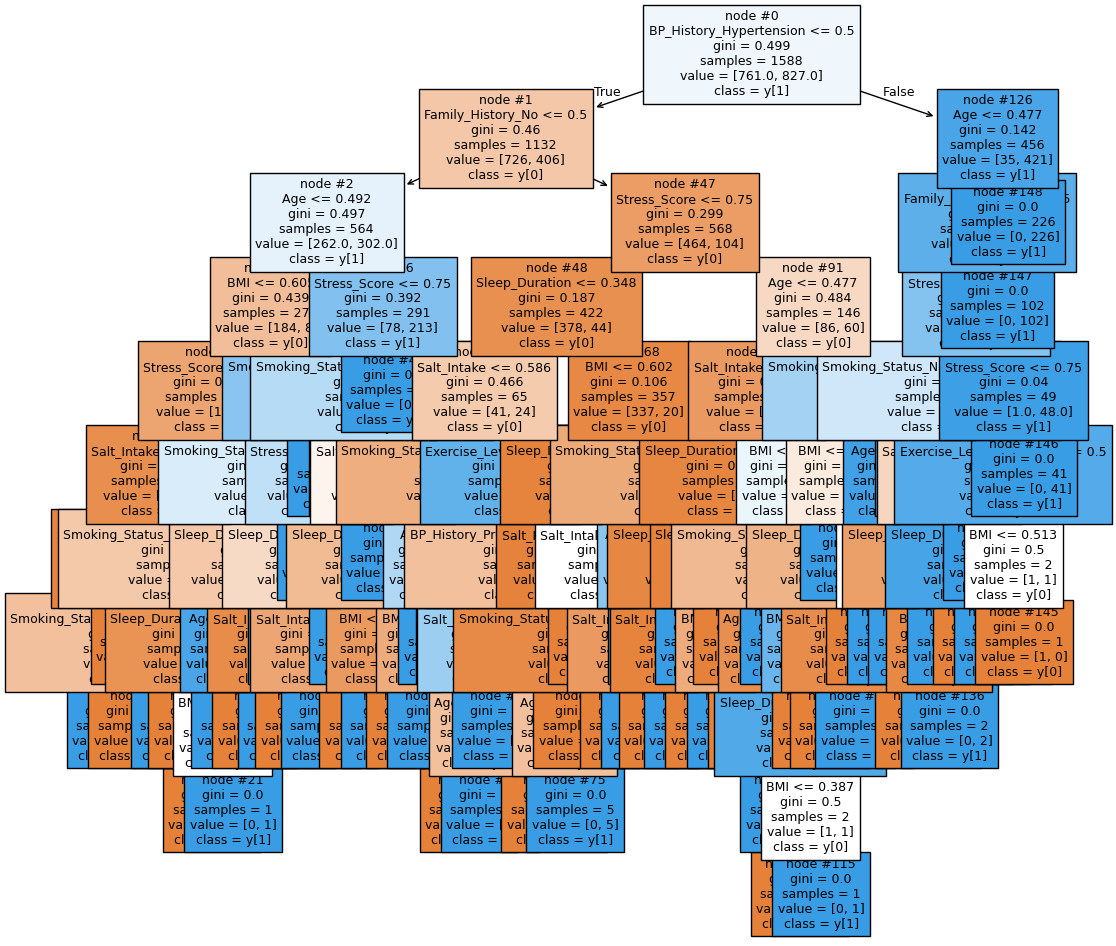

In [57]:
from sklearn.tree import plot_tree
from sklearn import metrics
import matplotlib.pyplot as plt
plt.figure(figsize = (12,12))
plot_tree(unpruned_tree, feature_names=X.columns, filled=True, fontsize=9, node_ids=True, class_names=True)
plt.show()

In [58]:
# this is overfitted model.. using entropy now

In [59]:
entropy_tree = DecisionTreeClassifier(criterion="entropy", random_state=42).fit(X_train, y_train)

In [60]:
score_train_entropy_tree = entropy_tree.score(X_train, y_train)
score_test_entropy_tree = entropy_tree.score(X_test, y_test)
train_scores_entropy = [score_train_entropy_tree]
test_scores_entropy = [score_test_entropy_tree]
model_list_entropy = ['entropy_tree']
score_dict_entropy = {
    'train_score_entropy':train_scores_entropy,
    'test_score_entropy':test_scores_entropy,
}
data_new_score_entropy = pd.DataFrame(score_dict_entropy, index=model_list_entropy)
data_new_score_entropy

,train_score_entropy,test_score_entropy
entropy_tree,1.0,0.969773


In [61]:
# increased accuracy with entropy from 0.962217 to 0.969773

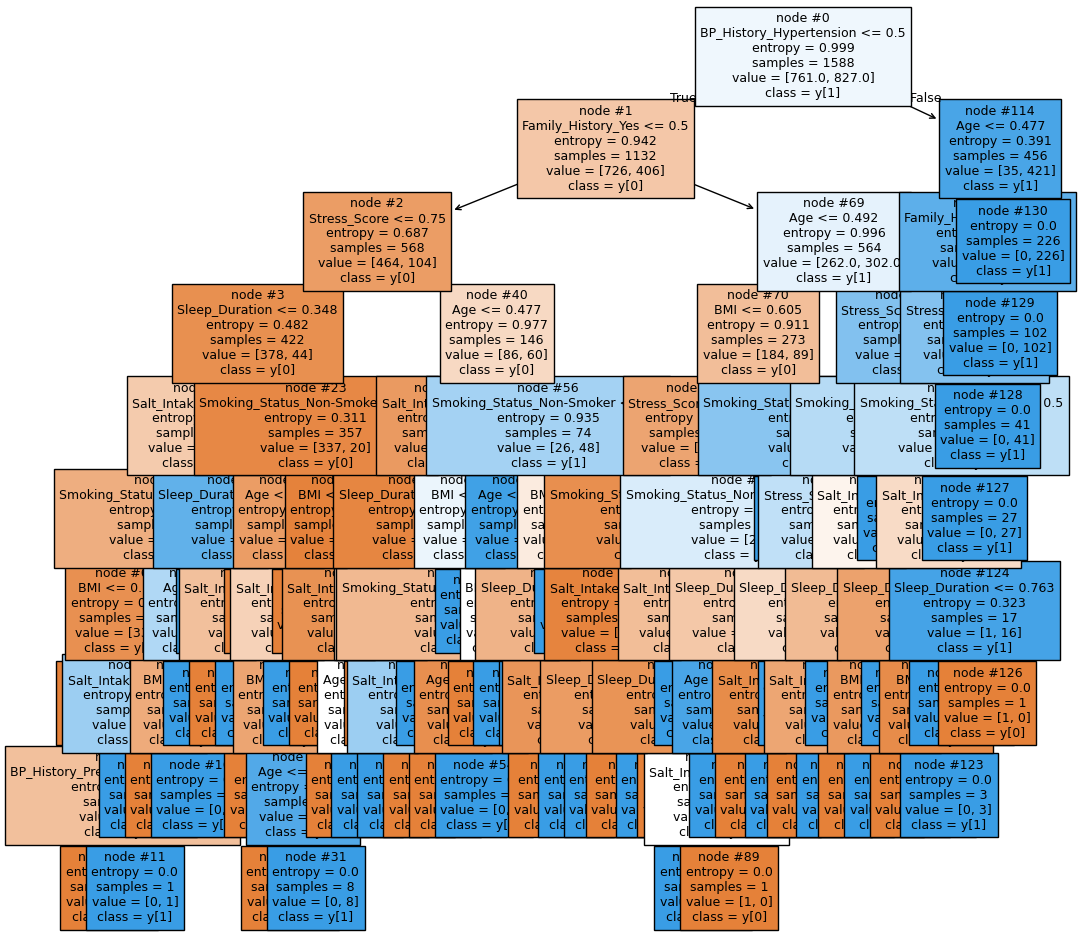

In [62]:
plt.figure(figsize = (12,12))
plot_tree(entropy_tree, feature_names=X.columns, filled=True, fontsize=9, node_ids=True, class_names=True)
plt.show()

In [63]:
# still depth is more, so trying to reduce it now ... also leaf node are overfitting with sample size 1.. so keeping a check

In [64]:
pruned_tree = DecisionTreeClassifier(criterion="entropy", max_depth = 6, min_samples_split = 10, min_samples_leaf = 10, max_features = 6, random_state=42).fit(X_train, y_train)

In [65]:
score_train_pruned_tree = pruned_tree.score(X_train, y_train)
score_test_pruned_tree = pruned_tree.score(X_test, y_test)
train_scores_pruned = [score_train_pruned_tree]
test_scores_pruned = [score_test_pruned_tree]
model_list_pruned = ['pruned_tree']
score_dict_pruned = {
    'train_score_pruned':train_scores_pruned,
    'test_score_pruned':test_scores_pruned,
}
data_new_score_pruned = pd.DataFrame(score_dict_pruned, index=model_list_pruned)
data_new_score_pruned

,train_score_pruned,test_score_pruned
pruned_tree,0.895466,0.836272


In [66]:
# this reduces the accuracy, so increasing depth to 8 

In [74]:
pruned_8_tree = DecisionTreeClassifier(criterion="entropy", max_depth = 8 , min_samples_split = 10, min_samples_leaf = 10, random_state=42).fit(X_train, y_train)

In [75]:
score_train_pruned_8_tree = pruned_8_tree.score(X_train, y_train)
score_test_pruned_8_tree = pruned_8_tree.score(X_test, y_test)
train_scores_pruned_8 = [score_train_pruned_8_tree]
test_scores_pruned_8 = [score_test_pruned_8_tree]
model_list_pruned_8 = ['pruned_8_tree']
score_dict_pruned_8 = {
    'train_score_pruned_8':train_scores_pruned_8,
    'test_score_pruned_8':test_scores_pruned_8,
}
data_new_score_pruned_8 = pd.DataFrame(score_dict_pruned_8, index=model_list_pruned_8)
data_new_score_pruned_8

,train_score_pruned_8,test_score_pruned_8
pruned_8_tree,0.964106,0.929471


In [69]:
# this is still less accuracy so increasing depth to 9

In [72]:
pruned_9_tree = DecisionTreeClassifier(criterion="entropy", max_depth = 9 , min_samples_split = 10, min_samples_leaf = 10, random_state=42).fit(X_train, y_train)

In [73]:
score_train_pruned_9_tree = pruned_9_tree.score(X_train, y_train)
score_test_pruned_9_tree = pruned_9_tree.score(X_test, y_test)
train_scores_pruned_9 = [score_train_pruned_9_tree]
test_scores_pruned_9 = [score_test_pruned_9_tree]
model_list_pruned_9 = ['pruned_9_tree']
score_dict_pruned_9 = {
    'train_score_pruned_9':train_scores_pruned_9,
    'test_score_pruned_9':test_scores_pruned_9,
}
data_new_score_pruned_9 = pd.DataFrame(score_dict_pruned_9, index=model_list_pruned_9)
data_new_score_pruned_9

,train_score_pruned_9,test_score_pruned_9
pruned_9_tree,0.964106,0.929471


In [76]:
# entropy_tree had most accuracy with the depth of 10.. so we conclude that's the best model 

In [ ]:
# now generating confusion matrix for best model 

Confusion Matrix:
 [[184   8]
 [  4 201]]


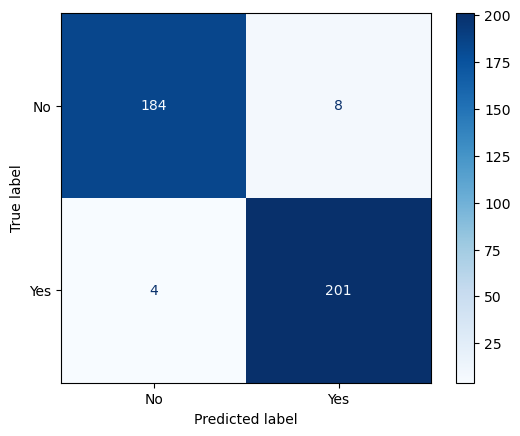

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = entropy_tree.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=entropy_tree.classes_)
disp.plot(cmap="Blues", values_format="d")


In [79]:
# classification report 

In [80]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.98      0.96      0.97       192
         Yes       0.96      0.98      0.97       205

    accuracy                           0.97       397
   macro avg       0.97      0.97      0.97       397
weighted avg       0.97      0.97      0.97       397



In [ ]:
# extracting and displaying top 5 features importance 

                   Feature  Importance
5  BP_History_Hypertension    0.215659
1              Salt_Intake    0.125525
0                      Age    0.116723
4                      BMI    0.116322
3           Sleep_Duration    0.115742


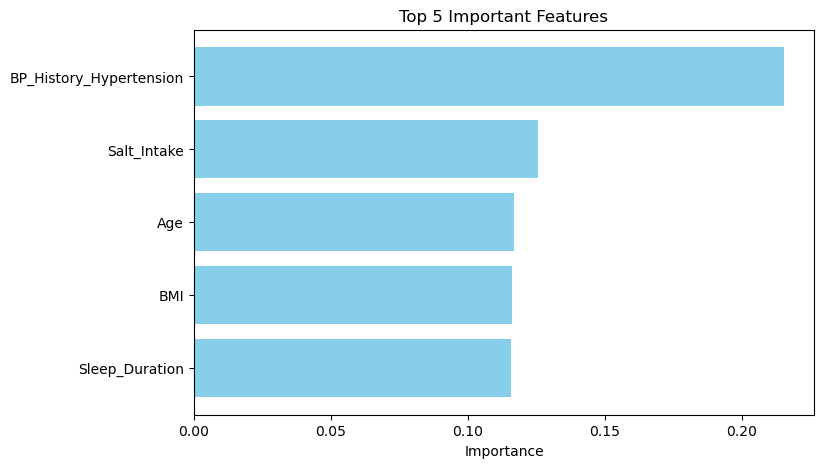

In [82]:
importances = entropy_tree.feature_importances_
feature_names = X.columns
feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
top_features = feature_importances.sort_values(by='Importance', ascending=False).head(5)

print(top_features)

# Optional: nice bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.xlabel("Importance")
plt.title("Top 5 Important Features")
plt.gca().invert_yaxis()
plt.show()


In [83]:
# interpretation of these features in medical field

In [87]:
""" 
1. BP_History_Hypertension (0.126)
    Past or existing hypertension is a major risk factor for cardiovascular diseases.
    It strongly influences whether someone is classified as at risk (or not) because high blood pressure stresses the heart and vessels.
2. Salt_Intake (0.126)
    High sodium intake is well-known to increase blood pressure.
    It directly affects hypertension risk and therefore is medically significant.
3. Age (0.117)
    With aging, arteries stiffen and risk of hypertension, stroke, and heart disease increases.
    Age is a natural predictor in most health-related classification tasks.
4. BMI (0.116)
    Higher body mass index indicates overweight/obesity, which is linked to hypertension, diabetes, and metabolic syndrome.
    It’s logically important because excess weight strains the cardiovascular system.
5. Sleep_Duration (0.116)
    Poor or insufficient sleep is associated with stress, hormonal imbalance, and hypertension.
    Both too little and too much sleep can contribute to cardiovascular issues. 
"""

' \n1. BP_History_Hypertension (0.126)\n    Past or existing hypertension is a major risk factor for cardiovascular diseases.\n    It strongly influences whether someone is classified as at risk (or not) because high blood pressure stresses the heart and vessels.\n2. Salt_Intake (0.126)\n    High sodium intake is well-known to increase blood pressure.\n    It directly affects hypertension risk and therefore is medically significant.\n3. Age (0.117)\n    With aging, arteries stiffen and risk of hypertension, stroke, and heart disease increases.\n    Age is a natural predictor in most health-related classification tasks.\n4. BMI (0.116)\n    Higher body mass index indicates overweight/obesity, which is linked to hypertension, diabetes, and metabolic syndrome.\n    It’s logically important because excess weight strains the cardiovascular system.\n5. Sleep_Duration (0.116)\n    Poor or insufficient sleep is associated with stress, hormonal imbalance, and hypertension.\n    Both too little 